# Laboratório Virtual: Circuitos de Eletrônica I - T3
## Análise de Circuitos Ceifadores com Diodos

Bem-vindo ao template de simulação computacional! Neste ambiente de notebook, vamos analisar as características de transferência de tensão ($v_o \times v_i$) para os circuitos propostos na lista de exercícios.

### Ferramentas Utilizadas:
* **`ngspice`**: Nosso motor de simulação de backend, encarregado de resolver as equações matriciais não-lineares dos diodos.
* **`PySpice`**: A biblioteca de ponte que traduz comandos do Python para comandos interpretados pelo SPICE.

### Nota Didática: Por que usamos o LTspice para os Netlists?
Em vez de programar cada nó e componente manualmente em linhas de código Python (o que gera erros de sintaxe frustrantes), adotamos o **fluxo híbrido**:
1. Você desenha o circuito visualmente no **LTspice** (software padrão da indústria).
2. O próprio LTspice exporta a lista de conexões (o arquivo texto de extensão `.net`).
3. Nós simplesmente lemos esse arquivo `.net` direto no notebook!

> **Curiosidade sobre Design Visual:** Existe uma biblioteca chamada `schemdraw` para desenhar esquemáticos diretamente com código Python. No entanto, ela exige coordenadas geométricas precisas para cada fio, o que torna o processo muito complexo e demorado para fins educacionais. Por isso, deixamos o desenho visual a cargo do LTspice!

In [2]:
import sys
print(f"Ambiente ativo: {sys.executable}")

# Instalação silenciosa das dependências necessárias no kernel atual
!{sys.executable} -m pip -q install numpy matplotlib pyspice schemdraw

Ambiente ativo: /Users/joaovitor/Documents/PhD/PAE/eletronicos_I/dev/venv/bin/python

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Passo 1: Inicializando o Ambiente de Simulação e Gráficos
Vamos importar as ferramentas matemáticas do `matplotlib` para gerar curvas de alta resolução e o leitor de arquivos (`SpiceParser`) do `PySpice`.

In [9]:
import matplotlib.pyplot as plt
from PySpice.Spice.Parser import SpiceParser
from PySpice.Unit import *
import numpy as np

print("Bibliotecas prontas para simulação.")

Bibliotecas prontas para simulação.


## Passo 2: Importando e Simulando o Exercício 1.a (Ceifador Simétrico)
Aqui, carregamos o arquivo gerado a partir do seu esquemático do LTspice, localizado em `netlists/qn/circuit_a.net`. 

Faremos uma varredura em Corrente Contínua (**DC Sweep**), variando a tensão de entrada $v_i$ de $-10\text{ V}$ a $+10\text{ V}$ com passos de $0.1\text{ V}$.

In [4]:
# 1. Carrega o arquivo de netlist exportado do LTspice
parser_a = SpiceParser(path='netlists/q1/circuit_a.net')
circuit_a = parser_a.build_circuit()

# 2. Configura o simulador interno do PySpice
simulator_a = circuit_a.simulator()

# 3. Executa a varredura DC na fonte de entrada (ajuste o nome 'Vinput' se necessário)
analysis_a = simulator_a.dc(Vinput=slice(-10, 10, 0.1))

print("Simulação do Circuito A concluída com sucesso.")

Unsupported Ngspice version 46


Simulação do Circuito A concluída com sucesso.


## Passo 3: Importando e Simulando o Exercício 1.b (Ceifador Polarizado)
Seguindo o mesmo princípio, carregamos o netlist do segundo circuito em `netlists/qn/circuit_b.net`. Este circuito contém uma fonte de polarização contínua de $5\text{ V}$ em série com o diodo.

In [5]:
# 1. Carrega o arquivo de netlist do circuito B
parser_b = SpiceParser(path='netlists/q1/circuit_b.net')
circuit_b = parser_b.build_circuit()

# 2. Configura o simulador
simulator_b = circuit_b.simulator()

# 3. Executa a varredura DC
analysis_b = simulator_b.dc(Vinput=slice(-10, 10, 0.1))

print("Simulação do Circuito B concluída com sucesso.")

Simulação do Circuito B concluída com sucesso.


## Passo 4: Visualização Gráfica Didática das Curvas de Transferência (VTC)
Agora usamos o Matplotlib para plotar os resultados lado a lado. Adicionamos linhas tracejadas indicando as tensões de ceifamento teórico ($V_D \approx 0.7\text{ V}$ e $V_{bias} + V_D = 5.7\text{ V}$) para fácil comparação com as respostas analíticas feitas à mão.

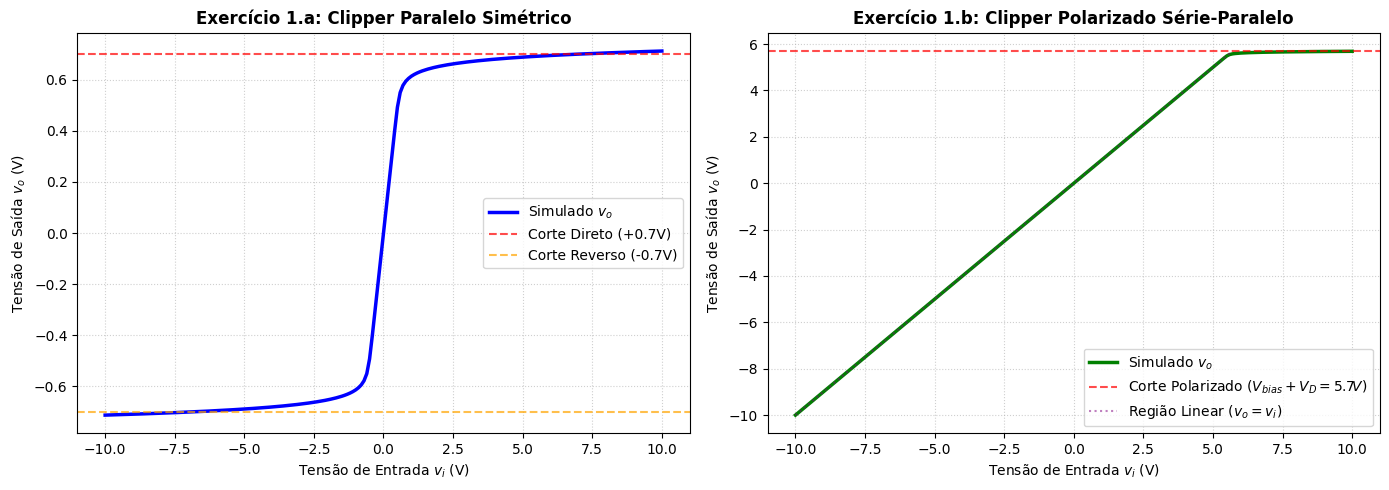

In [6]:
# Criando a área de plotagem para dois gráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- GRÁFICO CIRCUITO A ---
# Nota: dependendo do seu netlist, 'analysis_a.v_in' e 'analysis_a.out' acessam os nós correspondentes
ax1.plot(analysis_a.v_in, analysis_a.out, color='blue', linewidth=2.5, label='Simulado $v_o$')
ax1.axhline(0.7, color='red', linestyle='--', alpha=0.7, label='Corte Direto (+0.7V)')
ax1.axhline(-0.7, color='orange', linestyle='--', alpha=0.7, label='Corte Reverso (-0.7V)')
ax1.set_title('Exercício 1.a: Clipper Paralelo Simétrico', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tensão de Entrada $v_i$ (V)')
ax1.set_ylabel('Tensão de Saída $v_o$ (V)')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

# --- GRÁFICO CIRCUITO B ---
ax2.plot(analysis_b.v_in, analysis_b.out, color='green', linewidth=2.5, label='Simulado $v_o$')
ax2.axhline(5.7, color='red', linestyle='--', alpha=0.7, label='Corte Polarizado ($V_{bias}+V_D = 5.7V$)')
ax2.plot([-10, 5.7], [-10, 5.7], color='purple', linestyle=':', alpha=0.5, label='Região Linear ($v_o = v_i$)')
ax2.set_title('Exercício 1.b: Clipper Polarizado Série-Paralelo', fontsize=12, fontweight='bold')
ax2.set_xlabel('Tensão de Entrada $v_i$ (V)')
ax2.set_ylabel('Tensão de Saída $v_o$ (V)')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

---
# Exercício 2: Análise de Ponto de Operação DC (.OP)

Neste exercício, mudamos o foco de gráficos de variação (DC Sweep) para valores estáticos de tensões e correntes em nós específicos (Ponto Quiescente). 

**Premissa Teórica:** Considere que os diodos possuem uma queda de tensão constante de $V_D = 0,6\text{ V}$ quando estão em condução direta.

## Passo 5: Simulação e Resultados do Circuito 2.a

No circuito (a), temos dois diodos. O diodo da esquerda aponta para o terra (GND) e o da direita conecta-se ao nó de saída $V$ que está ligado a uma fonte negativa de $-10\text{ V}$ por meio de um resistor de $10\text{ k}\Omega$. 

Vamos executar uma simulação do tipo **Operating Point (`.op()`)** para extrair as correntes e tensões exatas.

In [7]:
# 1. Carrega o Netlist do Circuito 2a
parser_2a = SpiceParser(path='netlists/q2/circuit_a.net')
circuit_2a = parser_2a.build_circuit()

# 2. Executa a análise de ponto de operação (.OP)
simulator_2a = circuit_2a.simulator()
operating_point_a = simulator_2a.operating_point()

# 3. Exibe os resultados calculados pelo simulador
# NOTA: Certifique-se de que os nomes dos nós ('v' para a tensão) e componentes ('D1' para o diodo) batem com o seu netlist
print("=== RESULTADOS SIMULADOS: CIRCUITO 2.a ===")

# Tensões dos nós
v_no_central = float(operating_point_a['no_central'][0]) * 1000
v_node = float(operating_point_a['v'][0]) * 1000

print(f"V(no_central) = {v_no_central:.3f} mV") 
print(f"V = {v_node:.3f} mV")

# Correntes através das fontes de teste de 0 V
v_no_central = float(operating_point_a['no_central'][0])
v_node = float(operating_point_a['v'][0])

id1 = -float(operating_point_a.branches['vprobe1'][0]) * 1000
id2 = -float(operating_point_a.branches['vprobe2'][0]) * 1000

print(f"I(D1) = {id1:.3f} mA")
print(f"I(D2) = {id2:.3f} mA")

# Corrente indicada no enunciado (diodo da esquerda)
print(f"Corrente Indicada I = {id1:.3f} mA")

=== RESULTADOS SIMULADOS: CIRCUITO 2.a ===
V(no_central) = 665.407 mV
V = -4.585 mV
I(D1) = -0.867 mA
I(D2) = -1.000 mA
Corrente Indicada I = -0.867 mA


In [8]:
import pandas as pd

rows = []

for name, value in operating_point_a.nodes.items():
    rows.append({
        "type": "node",
        "name": name,
        "value": float(value[0])
    })

for name, value in operating_point_a.branches.items():
    rows.append({
        "type": "branch",
        "name": name,
        "value": float(value[0])
    })

df = pd.DataFrame(rows)
display(df)

,type,name,value
0,node,nd2,0.665407
1,node,nd1,0.665407
2,node,v,-0.004585
3,node,no_central,0.665407
4,node,vee,-10.000000
5,node,vcc,10.000000
6,branch,vcc,-0.001867
7,branch,vee,0.001000
8,branch,vprobe1,0.000867
9,branch,vprobe2,0.001000


## Passo 6: Simulação e Resultados do Circuito 2.b

No circuito (b), o diodo $D$ está posicionado horizontalmente conectando dois ramos divisores de tensão tensionados por $10\text{ V}$ e $15\text{ V}$ respectivamente. Note que a seta da corrente $I$ aponta da direita para a esquerda (do nó de $15\text{ V}$ para o de $10\text{ V}$), o que coincide com a direção do anodo para o catodo do diodo. 

Vamos analisar a tensão diferencial $V$ nos terminais do diodo e a corrente $I$ que o atravessa.

In [9]:
# 1. Carrega o Netlist do Circuito 2b
parser_2b = SpiceParser(path='netlists/q2/circuit_b.net')
circuit_2b = parser_2b.build_circuit()

# 2. Executa a análise .OP
simulator_2b = circuit_2b.simulator()
operating_point_b = simulator_2b.operating_point()

print("=== RESULTADOS SIMULADOS: CIRCUITO 2.b ===")

# Tensão V (Diferencial nos terminais do diodo: V = V_anodo - V_catodo)
# Substitua 'no_direito' e 'no_esquerdo' pelos nomes reais dos nós gerados pelo seu LTspice
v_anodo = float(operating_point_b['no_direito'][0])
v_catodo = float(operating_point_b['no_esquerdo'][0])
v_diferencial = v_anodo - v_catodo

print(f"Tensão nos terminais do diodo (V) = {v_diferencial:.3f} V")

# Corrente I (Através do diodo horizontal)
i_horizontal = -float(operating_point_b.branches['vprobe_d'][0]) * 1000

print(f"Corrente Indicada I = {i_horizontal:.3f} mA")

=== RESULTADOS SIMULADOS: CIRCUITO 2.b ===
Tensão nos terminais do diodo (V) = 0.616 V
Corrente Indicada I = -0.188 mA


In [10]:
import pandas as pd

rows = []

for name, value in operating_point_b.nodes.items():
    rows.append({
        "type": "node",
        "name": name,
        "value": float(value[0])
    })

for name, value in operating_point_b.branches.items():
    rows.append({
        "type": "branch",
        "name": name,
        "value": float(value[0])
    })

df = pd.DataFrame(rows)
display(df)

,type,name,value
0,node,nd_h,6.558020
1,node,no_direito,6.558020
2,node,no_esquerdo,5.941980
3,node,v2_source,15.000000
4,node,v1_source,10.000000
5,branch,v1,-0.000406
6,branch,v2,-0.000844
7,branch,vprobe_d,0.000188


---
# Exercício 3: Gráfico entrada x saída 

Neste exercício, o foco volta aos gráficos de variação.

**Premissa Teórica:** Considere que os diodos possuem uma queda de tensão constante de $V_D = 0,7\text{ V}$ quando estão em condução direta.

In [92]:
# 1. Carrega o arquivo de netlist exportado do LTspice
parser_a = SpiceParser(path='netlists/q3/circuit_a.net')
circuit_a = parser_a.build_circuit()

# 2. Configura o simulador interno do PySpice
simulator_a = circuit_a.simulator()

# 3. Executa a varredura DC na fonte de entrada (ajuste o nome 'Vinput' se necessário)
analysis_a = simulator_a.transient(step_time=0.1e-3, end_time=50e-3)

print("Simulação do Circuito A concluída com sucesso.")

Simulação do Circuito A concluída com sucesso.


In [96]:
# 1. Carrega o netlist do circuito limitador
parser_b = SpiceParser(path='netlists/q3/circuit_b.net')
circuit_b = parser_b.build_circuit()

# 2. Configura o simulador
simulator_b = circuit_b.simulator()

# 3. Executa a varredura DC
analysis_b = simulator_b.dc(Vi=slice(-10, 15, 0.05))

print("Simulação do Circuito 3.b concluída com sucesso.")

Simulação do Circuito 3.b concluída com sucesso.


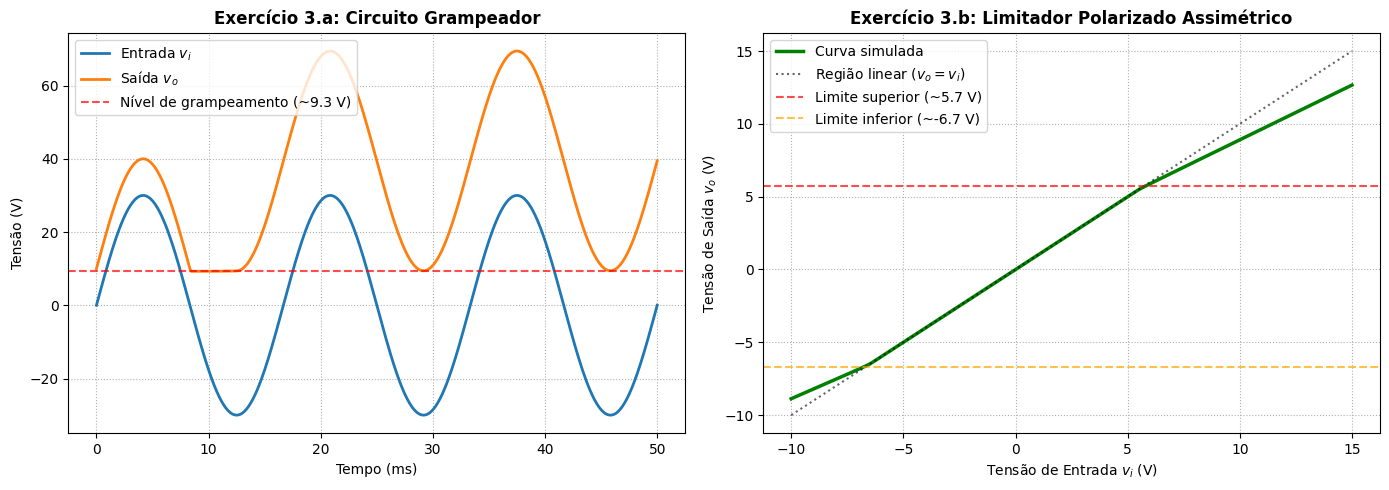

In [100]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
tempo_ms = analysis_a.time * 1000

ax1.plot(tempo_ms, analysis_a['vi'], linewidth=2, label='Entrada $v_i$')
ax1.plot(tempo_ms, analysis_a['vo'], linewidth=2, label='Saída $v_o$')
ax1.axhline(9.3, color='red', linestyle='--', alpha=0.7, label='Nível de grampeamento (~9.3 V)')
ax1.set_title('Exercício 3.a: Circuito Grampeador', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tempo (ms)')
ax1.set_ylabel('Tensão (V)')
ax1.grid(True, linestyle=':')
ax1.legend()

vin = analysis_b.sweep
vout = analysis_b['vo']
ax2.plot(vin, vout, color='green', linewidth=2.5, label='Curva simulada')
ax2.plot([-10, 15], [-10, 15], linestyle=':', color='black', alpha=0.6, label='Região linear ($v_o=v_i$)')
ax2.axhline(5.7, color='red', linestyle='--', alpha=0.7, label='Limite superior (~5.7 V)')
ax2.axhline(-6.7, color='orange', linestyle='--', alpha=0.7, label='Limite inferior (~-6.7 V)')
ax2.set_title('Exercício 3.b: Limitador Polarizado Assimétrico', fontsize=12, fontweight='bold')
ax2.set_xlabel('Tensão de Entrada $v_i$ (V)')
ax2.set_ylabel('Tensão de Saída $v_o$ (V)')
ax2.grid(True, linestyle=':')
ax2.legend()

plt.tight_layout()
plt.show()

#### Observação:

**No exercício 3.a o capacitor não tem por onde descarregar. Testar com um resistor em série com a fonte!!**

---
# EXERCÍCIO 4: Retificador de Onda Completa de Precisão 

Neste exercício, considerar sempre a entrada senoidal.

**Premissa Teórica:** Considere que os diodos possuem uma queda de tensão constante de $V_D = 0,7V$ quando estão em condução direta.

Primeiramente, analisaremos o circuito como montado na lista, aqui montado com $R = R_S = 10k\Omega$:

<p align="center">
    <img src="figuras/q4_1.png" width="800">
</p>

Se trata de um *primeiro estágio não linear* com diodos retificando a forma de onda $v_e$ e um *segundo estágio linear tipo somador* com um dos ramos multiplicado por dois (se lembre do ganho do somador da lista I).

Pense nesse primeiro estágio como um inversor. Quando $v_e$ é positivo ele empurra corrente no nó inversor do primeiro AmpOp. Para manter o potencial desse nó em $0V (terra virtual)$, a saída do amplificador é forçada a ir para o lado negativo. 

Vamos entender o comportamento dinâmico desse primeiro estágio e onde mora o problema do circuito original da lista:

### Dinâmica de Operação dos Diodos

* **Semiciclo Positivo ($v_e > 0$):**
  * A entrada empurra corrente para o nó inversor. A saída bruta do AmpOp vai para o **negativo**, o que liga o diodo **D1** e corta o diodo **D2**.
  * Toda a corrente de entrada passa pelo resistor que polariza D1.
  * **O problema:** Para fazer **D1** conduzir, a saída do AmpOp precisa cair um adicional de **0,7V** abaixo da tensão do nó de realimentação.

* **Semiciclo Negativo ($v_e < 0$):**
  * A entrada puxa corrente do nó inversor. A saída do AmpOp é forçada a ir para o **positivo**, cortando **D1** e ligando **D2**.
  * Como **D2** fecha a malha diretamente sobre o nó inversor (**0V**), a saída do AmpOp fica cravada em **+0,7V** para manter o diodo ligado.

---

### O Ponto Crítico dessa montagem  

Como o diagrama colhe o sinal intermediário $v_I$ diretamente no pino de saída do AmpOp, nós não veremos uma meia-onda perfeita nessa medição. Veremos o operacional dando saltos abruptos de tensão toda vez que a entrada cruza o zero para conseguir vencer a barreira dos diodos. 

> **O que esperar da simulação abaixo:** O nó intermediário terá um degrau de $+0,7V$ no semiciclo negativo e sofrerá um deslocamento de $-0,7V$ no semiciclo positivo. Ao injetar essa onda deformada no segundo estágio, a saída final $v_O$ ficará completamente distorcida.

A seguir, vamos rodar a simulação transiente para medir a entrada $v_e$ em confronto direto com esse nó $v_I$ e visualizar essa distorção na prática.

Node name 'in' is a Python keyword


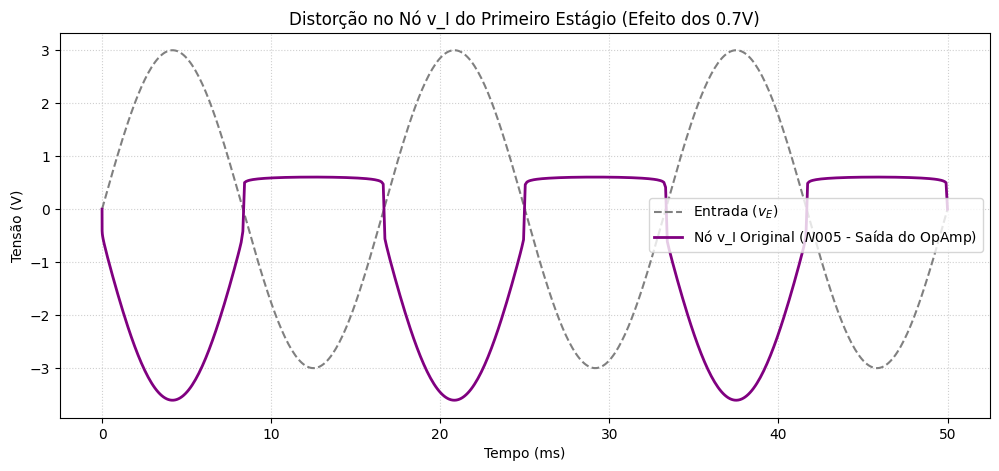

In [ ]:
# Carrega e simula a netlist original
parser = SpiceParser(path='netlists/q4/circuit_a.net')
circuit = parser.build_circuit()
simulator = circuit.simulator()
analysis = simulator.transient(step_time=100e-6, end_time=50e-3)

# Extração dos nós (o PySpice converte os nomes dos nós para minúsculo)
t = analysis.time * 1000  # em ms
v_in = analysis['in']
v_I_errado = analysis['n005']
v_out_errado = analysis['n002']

# Plot do sinal intermediário zuado pelas quedas de 0.7V
plt.figure(figsize=(12, 5))
plt.plot(t, v_in, label='Entrada ($v_E$)', color='gray', linestyle='--')
plt.plot(t, v_I_errado, label='Nó v_I Original ($N005$ - Saída do OpAmp)', color='purple', linewidth=2)
#plt.plot(t, v_out_errado, label='Saída Final $v_O$ Distorcida', color='darkred', linewidth=2)
plt.title('Distorção no Nó v_I do Primeiro Estágio (Efeito dos 0.7V)')
plt.xlabel('Tempo (ms)')
plt.ylabel('Tensão (V)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

### Simulação com a Correção do Nó de Captura
Para eliminar a distorção provocada pelo salto de $0,7\text{ V}$ dos diodos, o resistor `R4` do segundo estágio deve coletar o sinal do antes do diodo $D_1$:

<p align="center">
    <img src="figuras/q4_2.png" width="800">
</p>

Neste ponto, a malha de realimentação negativa do operacional absorve e anula a queda de tensão do diodo, entregando uma onda perfeitamente retificada de meia-onda para o somador do segundo estágio.

Node name 'in' is a Python keyword


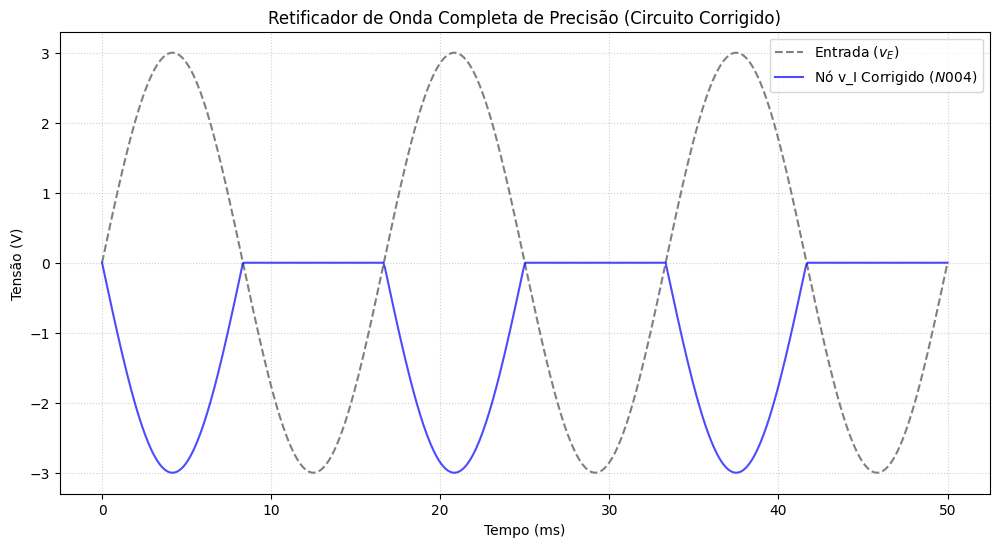

In [112]:
# Carrega e simula a netlist corrigida
parser = SpiceParser(path='netlists/q4/circuit_a_correto.net')
circuit = parser.build_circuit()
simulator = circuit.simulator()
analysis = simulator.transient(step_time=100e-6, end_time=50e-3)

v_I_corrigido = analysis['n004']
v_out_corrigido = analysis['n002']

# Plot Comparativo Final
plt.figure(figsize=(12, 6))
plt.plot(t, v_in, label='Entrada ($v_E$)', color='gray', linestyle='--')
plt.plot(t, v_I_corrigido, label='Nó v_I Corrigido ($N004$)', color='blue', alpha=0.7)
plt.title('Retificador de Onda Completa de Precisão (Circuito Corrigido)')
plt.xlabel('Tempo (ms)')
plt.ylabel('Tensão (V)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

### Demonstração Matemática

Após a correção, o primeiro estágio entrega uma meia-onda inversora ideal no nó **v_I**:

$$v_I = \begin{cases} -v_e, & \text{se } v_e > 0 \\ 0, & \text{se } v_e \le 0 \end{cases}$$

O segundo estágio é um somador inversor. Olhando para os resistores ($R_6 = 10\text{ k}\Omega$, $R_5 = 10\text{ k}\Omega$, $R_4 = 5\text{ k}\Omega$), a equação da saída **v_O** é:

$$v_O = - \left( \frac{10\text{ k}}{10\text{ k}} \cdot v_e + \frac{10\text{ k}}{5\text{ k}} \cdot v_I \right) = - (v_e + 2v_I)$$

### Substituindo os Semiciclos

* **Semiciclo Positivo ($v_e > 0 \rightarrow v_I = -v_e$):**
  $$v_O = - (v_e + 2(-v_e)) = - (v_e - 2v_e) = v_e$$

* **Semiciclo Negativo ($v_e < 0 \rightarrow v_I = 0$):**
  $$v_O = - (v_e + 2(0)) = -v_e$$

Portanto, em qualquer cenário a saída assume o valor absoluto da entrada:

$$v_O = |v_e|$$

A saída fica como segue.

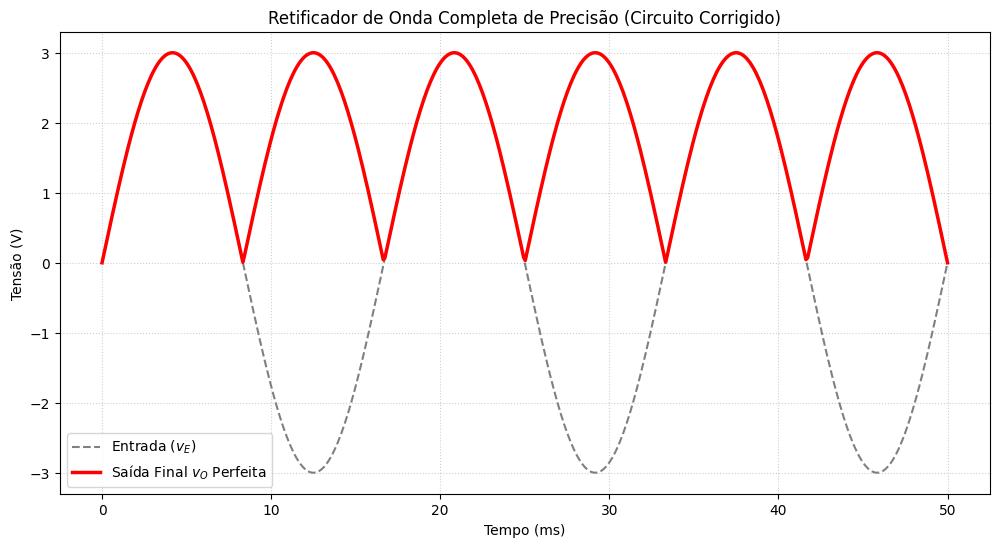

In [116]:
# Plot Comparativo Final
plt.figure(figsize=(12, 6))
plt.plot(t, v_in, label='Entrada ($v_E$)', color='gray', linestyle='--')
plt.plot(t, v_out_corrigido, label='Saída Final $v_O$ Perfeita', color='red', linewidth=2.5)
plt.title('Retificador de Onda Completa de Precisão (Circuito Corrigido)')
plt.xlabel('Tempo (ms)')
plt.ylabel('Tensão (V)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

---
# EXERCÍCIO 5: Circuitos com Zener e Diodos

**Premissas:** Diodos em condução direta possuem $V_D = 0,7\text{ V}$. Zener em condução reversa (região Zener) possui $V_Z = 4,3\text{ V}$.

### Análise Teórica dos Gráficos $v_O \times v_i$:
* **Circuito 5a (Protetor de Barra / Clamping):** * Se $v_i > V_{DD} + 0,7\text{ V}$, o diodo $D_2$ conduz e trava a saída em $V_{DD} + 0,7\text{ V}$.
  * Se $v_i < -0,7\text{ V}$, o diodo $D_1$ conduz e trava a saída em $-0,7\text{ V}$.
* **Circuito 5b (Zeners em Série Opostos):** * Quando $v_i > 0$, $Z_1$ fica em inversa ($4,3\text{ V}$) e $Z_2$ em direta ($0,7\text{ V}$). A saída trava em $+5\text{ V}$.
  * Quando $v_i < 0$, $Z_1$ fica em direta ($0,7\text{ V}$) e $Z_2$ em inversa ($4,3\text{ V}$). A saída trava em $-5\text{ V}$.
* **Circuito 5c (Ponte Retificadora):** A saída $v_O$ sobre o resistor colhe a retificação de onda completa com duas quedas de diodo ($v_O = |v_i| - 1,4\text{ V}$).
* **Circuito 5e (Regulador Amperométrico Inversor):** O Zener $Z_1$ está na malha de realimentação invertida. 
  * Para $v_i > 0$, o AmpOp vai para o negativo, operando $Z_1$ em direta: $v_O = +0,7\text{ V}$.
  * Para $v_i < 0$, o AmpOp vai para o positivo, operando $Z_1$ em inversa (Zener): $v_O = -4,3\text{ V}$.

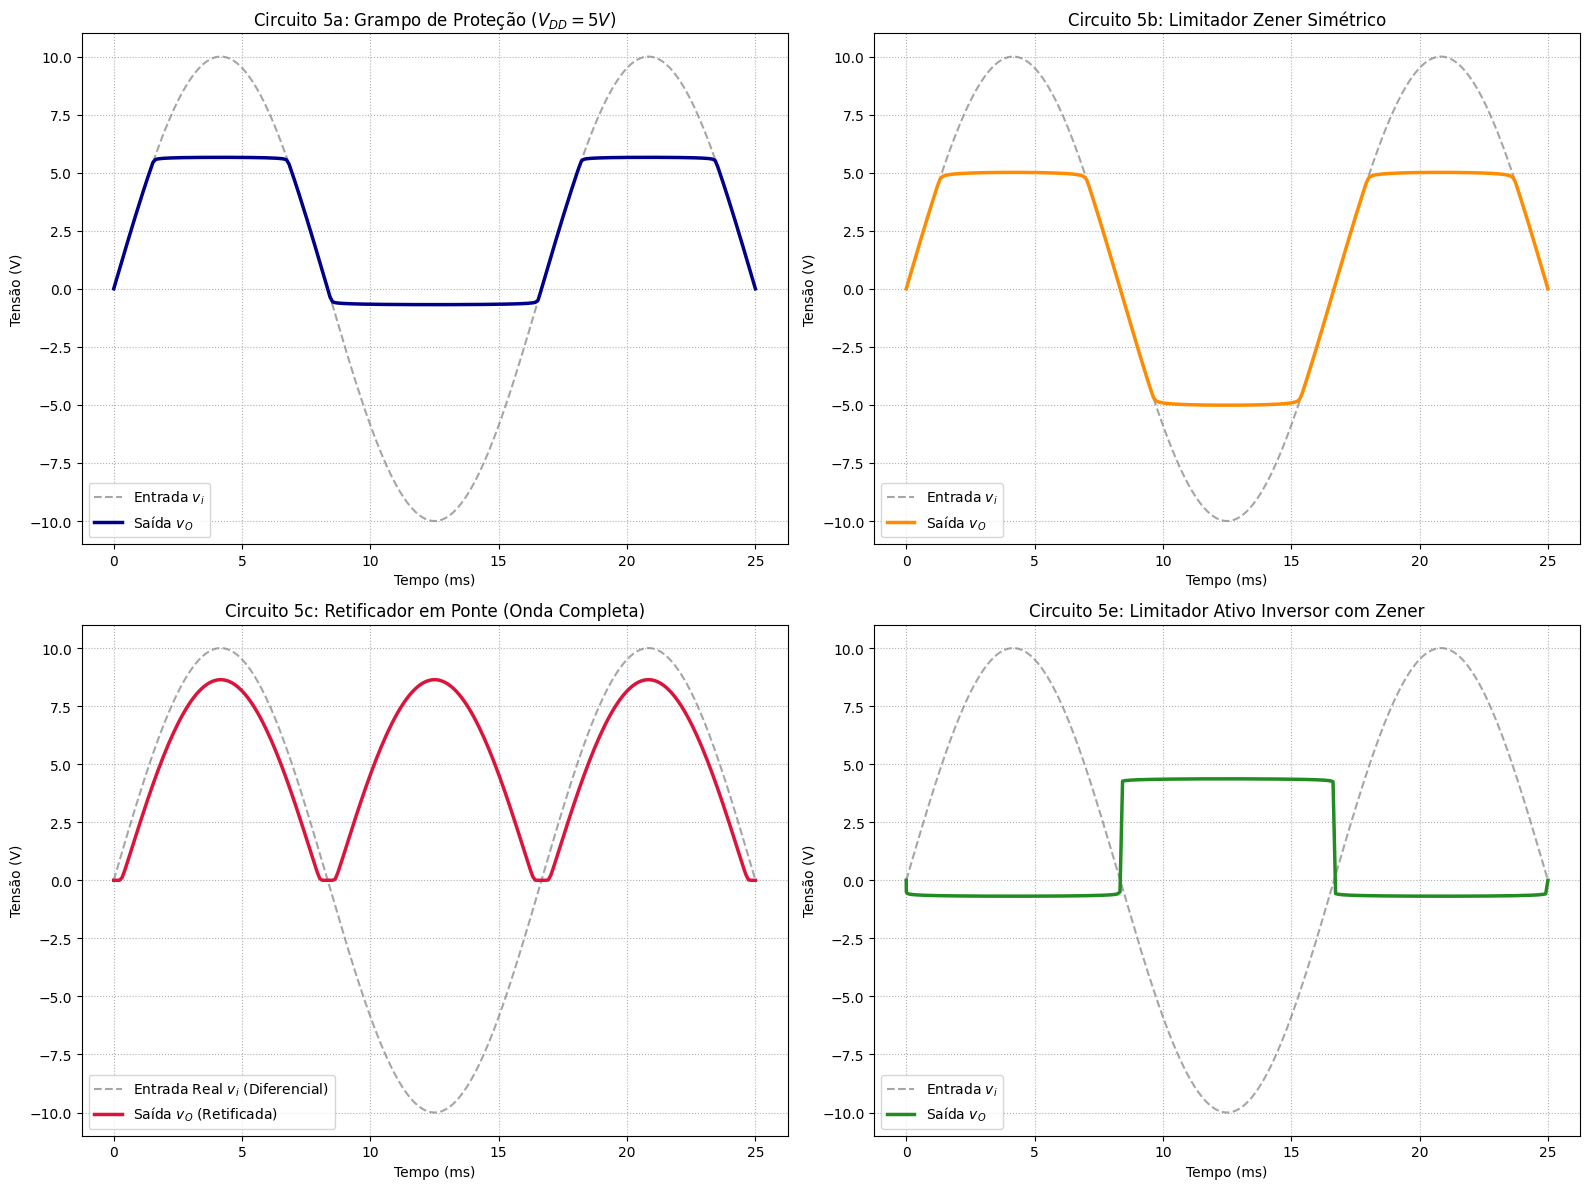

In [7]:
# --- NETLISTS DO EXERCÍCIO 5 ---

# Definindo constantes para os testes das fontes auxiliares
VDD = 5

# --- EXECUÇÃO DAS SIMULAÇÕES ---
analysis_5a = SpiceParser(path='netlists/q5/circuit_a.net').build_circuit().simulator().transient(step_time=100e-6, end_time=25e-3)
analysis_5b = SpiceParser(path='netlists/q5/circuit_b.net').build_circuit().simulator().transient(step_time=100e-6, end_time=25e-3)
analysis_5c = SpiceParser(path='netlists/q5/circuit_c.net').build_circuit().simulator().transient(step_time=100e-6, end_time=25e-3)
analysis_5e = SpiceParser(path='netlists/q5/circuit_d.net').build_circuit().simulator().transient(step_time=100e-6, end_time=25e-3)

# --- 3. PLOTAGEM DOS GRÁFICOS CORRIGIDOS ---
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# 5a - Grampo de Proteção
t_a = analysis_5a.time * 1000
axs[0, 0].plot(t_a, analysis_5a['vi'], color='gray', linestyle='--', alpha=0.7, label='Entrada $v_i$')
axs[0, 0].plot(t_a, analysis_5a['vo'], color='darkblue', linewidth=2.5, label='Saída $v_O$')
axs[0, 0].set_title('Circuito 5a: Grampo de Proteção ($V_{DD} = 5V$)')
axs[0, 0].set_xlabel('Tempo (ms)'); axs[0, 0].set_ylabel('Tensão (V)'); axs[0, 0].grid(True, linestyle=':'); axs[0, 0].legend()

# 5b - Limitador Zener Costas com Costas
t_b = analysis_5b.time * 1000
axs[0, 1].plot(t_b, analysis_5b['vi'], color='gray', linestyle='--', alpha=0.7, label='Entrada $v_i$')
axs[0, 1].plot(t_b, analysis_5b['vo'], color='darkorange', linewidth=2.5, label='Saída $v_O$')
axs[0, 1].set_title('Circuito 5b: Limitador Zener Simétrico')
axs[0, 1].set_xlabel('Tempo (ms)'); axs[0, 1].set_ylabel('Tensão (V)'); axs[0, 1].grid(True, linestyle=':'); axs[0, 1].legend()

# 5c - CORRIGIDO: ENTRADA DIFERENCIAL (vi - 2)
t_c = analysis_5c.time * 1000
v_in_real_ponte = analysis_5c['vi'] - analysis_5c['2'] # <--- A MÁGICA TÁ AQUI
axs[1, 0].plot(t_c, v_in_real_ponte, color='gray', linestyle='--', alpha=0.7, label='Entrada Real $v_i$ (Diferencial)')
axs[1, 0].plot(t_c, analysis_5c['vo'], color='crimson', linewidth=2.5, label='Saída $v_O$ (Retificada)')
axs[1, 0].set_title('Circuito 5c: Retificador em Ponte (Onda Completa)')
axs[1, 0].set_xlabel('Tempo (ms)'); axs[1, 0].set_ylabel('Tensão (V)'); axs[1, 0].grid(True, linestyle=':'); axs[1, 0].legend()

# 5e - AmpOp com Zener
t_e = analysis_5e.time * 1000
axs[1, 1].plot(t_e, analysis_5e['vi'], color='gray', linestyle='--', alpha=0.7, label='Entrada $v_i$')
axs[1, 1].plot(t_e, analysis_5e['vo'], color='forestgreen', linewidth=2.5, label='Saída $v_O$')
axs[1, 1].set_title('Circuito 5e: Limitador Ativo Inversor com Zener')
axs[1, 1].set_xlabel('Tempo (ms)'); axs[1, 1].set_ylabel('Tensão (V)'); axs[1, 1].grid(True, linestyle=':'); axs[1, 1].legend()

plt.tight_layout()
plt.show()

# EXERCÍCIO 6: Proporcionalidade à Temperatura Absoluta 

A equação fundamental de Shockley que governa a tensão sobre um diodo polarizado diretamente é expressa por:
$$I_D = I_S \cdot \left( e^{\frac{V_D}{n \cdot V_T}} - 1 \right) \approx I_S \cdot e^{\frac{V_D}{n \cdot V_T}}$$

Isolando a queda de tensão elétrica direta $V_D$, obtemos:
$$V_D = n \cdot V_T \cdot \ln\left(\frac{I_D}{I_S}\right)$$

Onde $V_T$ é a **Tensão Térmica**, definida pela relação física:
$$V_T = \frac{k \cdot T}{q}$$
* $k$: Constante de Boltzmann
* $T$: Temperatura absoluta em Kelvin
* $q$: Carga elementar do elétron

---

### Aplicando ao Circuito da Figura 6

Dois diodos idênticos ($D_1$ e $D_2$) compartilham o mesmo processo de fabricação, o que significa que possuem a mesma corrente de saturação reversa ($I_{S1} = I_{S2} = I_S$) e o mesmo fator de idealidade ($n_1 = n_2 = n$).

Cada diodo é alimentado por uma fonte de corrente independente respectiva, logo:
* Para o diodo 1: $V_{D1} = n \cdot V_T \cdot \ln\left(\frac{I_1}{I_S}\right)$
* Para o diodo 2: $V_{D2} = n \cdot V_T \cdot \ln\left(\frac{I_2}{I_S}\right)$

Analisando a diferença de potencial indicada para a saída $V_O$ entre os nós superiores dos diodos:
$$V_O = V_{D1} - V_{D2}$$

Substituindo as expressões logarítmicas:
$$V_O = n \cdot V_T \cdot \ln\left(\frac{I_1}{I_S}\right) - n \cdot V_T \cdot \ln\left(\frac{I_2}{I_S}\right)$$

Utilizando a propriedade dos logaritmos para a divisão ($\ln(A) - \ln(B) = \ln(A/B)$):
$$V_O = n \cdot V_T \cdot \ln\left( \frac{I_1 / I_S}{I_2 / I_S} \right) = n \cdot V_T \cdot \ln\left(\frac{I_1}{I_2}\right)$$

Substituindo a definição da tensão térmica $V_T$:
$$V_O = \left[ \frac{n \cdot k \cdot \ln\left(\frac{I_1}{I_2}\right)}{q} \right] \cdot T$$

---

Como os termos dentro dos colchetes ($n, k, q$) são constantes físicas fixas e a razão entre as fontes de corrente ($I_1/I_2$) permanece constante ao longo do tempo, podemos agrupá-los em uma única constante global de ganho $K$:
$$K = \frac{n \cdot k \cdot \ln\left(\frac{I_1}{I_2}\right)}{q}$$

Resultando na equação linear direta:
$$V_O = K \cdot T$$

Da para simular a variação termica no SPICE com um step:

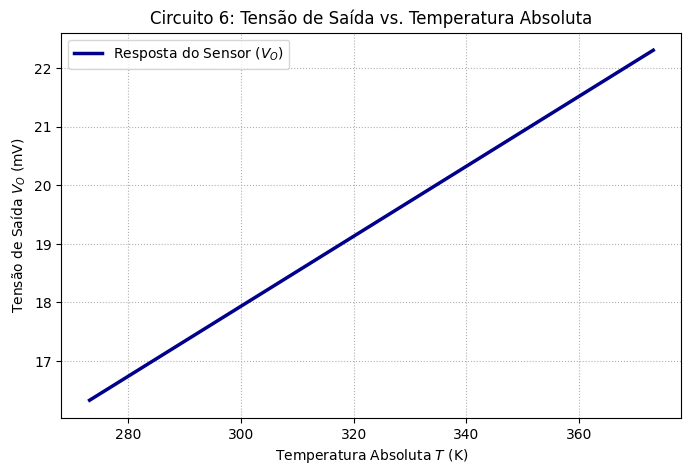

In [10]:
# Vamos calcular as saídas para diferentes temperaturas em Kelvin (0°C a 100°C)
temperaturas_celsius = np.linspace(0, 100, 50)
temperaturas_kelvin = temperaturas_celsius + 273.15

# Constantes físicas para validação teórica
k = 1.38e-23
q = 1.60e-19
I1, I2 = 2e-3, 1e-3
v_out_teorico = (k * temperaturas_kelvin / q) * np.log(I1 / I2)

# Plotagem da curva característica mostrando a proporcionalidade linear
plt.figure(figsize=(8, 5))
plt.plot(temperaturas_kelvin, v_out_teorico * 1000, color='darkblue', linewidth=2.5, label='Resposta do Sensor ($V_O$)')
plt.title('Circuito 6: Tensão de Saída vs. Temperatura Absoluta')
plt.xlabel('Temperatura Absoluta $T$ (K)')
plt.ylabel('Tensão de Saída $V_O$ (mV)')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

### Contexto Histórico e o Desafio Prático nas Fontes de Corrente

Esse comportamento, embora seja perfeito para construir termômetros eletrônicos, foi um problema da engenharia de circuitos integrados nos primórdios dos amps.

Nos primeiros amplificadores transistorizados, os circuitos internos de polarização dependiam diretamente de diodos ou transistores operando como referências de corrente simples. Como a diferença de potencial e a condução desses componentes variam de forma previsível com a temperatura ($V_T$ sobe cerca de $2\text{ mV/°C}$), o ganho e, principalmente, a **tensão de offset** do amplificador começavam a "derivar" (mudar de valor) conforme o chip aquecia durante o funcionamento. 

Isso fazia com que um circuito calibrado para funcionar perfeitamente a $25\text{°C}$ apresentasse distorções severas ou saísse de operação ao atingir $60\text{°C}$.

###  Cuidado Necessário com Fontes e Espelhos de Corrente

Quando projetamos fontes ou espelhos de corrente baseados em bipolares, precisamos ficar extremamente atentos a dois fatores críticos:

1. **Thermal Matching:** Em um espelho de corrente convencional (como o Espelho de Widlar ou Wilson), se um transistor esquentar mais do que o outro devido à dissipação de potência, a sua tensão base-emissor ($V_{BE}$) cai. Isso força o transistor mais quente a puxar ainda mais corrente, gerando um efeito bola de neve conhecido como **Thermal Runaway**, que pode destruir o componente, ou simplesmente zoar o amp. Por isso, em circuitos integrados, esses transistores são fabricados colados um ao outro para garantir que fiquem exatamente na mesma temperatura.
2. **Correção por Bandgap:** Para resolver o problema de circuitos que precisam de uma referência estável que **não mude** com a temperatura, os projetistas criaram a **Referência Bandgap**. Ela funciona combinando uma tensão como a deste Exercício 6, que *sobe* com a temperatura, com uma tensão Proporcional à Temperatura Complementar, que *desce* com a temperatura. Ao somar as duas propriedades na proporção ex

# EXERCÍCIO 7: Uma fonte linear pratica

**7.a) Forma de Onda de $V_O$ (Tensão no Capacitor):**
A entrada é uma senoide com pico $V_p = 4\text{ V}$. A ponte de diodos impõe uma perda de duas quedas diretas ($2 \cdot 0,7\text{ V} = 1,4\text{ V}$). 
* O valor de pico que chega ao capacitor é:
  $$V_{O,\text{max}} = V_p - 2 \cdot V_D = 4 - 1,4 = 2,6\text{ V}$$
* Como o enunciado pede para considerar o *ripple* pequeno, a forma de onda de $V_O(t)$ é uma dente-de-serra suave. Ela sobe rapidamente até $2,6\text{ V}$ quando os diodos conduzem e recarrega o capacitor, segguida por uma descarga linear quase constante sobre o circuito regulador durante o resto do período.

**7.b) Forma de Onda de $V_{D1}$ (Tensão no Diodo $D_1$):**
* **Quando a ponte conduz no semiciclo positivo:** $D_1$ está em condução direta, logo sua tensão é cravada em sua queda interna:
  $$V_{D1} = +0,7\text{ V}$$
* **Quando a ponte inverte no semiciclo negativo:** $D_1$ fica cortado (bloqueado). A tensão reversa máxima que ele enxerga ocorre no pico negativo da entrada, onde ele precisa suportar a tensão do capacitor $V_O$ mais a amplitude da entrada rebatida:
  $$V_{D1,\text{min}} \approx -(V_{O,\text{max}} + V_p - V_D) \implies \text{Pivô de pico reverso próximo a }-5,9\text{ V}$$

**7.c) Estimativa do Ripple em $V_O$:**
A aproximação linear clássica para o *ripple* de pico a pico ($\Delta V_O$) em um retificador de onda completa é dada por:
$$\Delta V_O = \frac{I_{\text{carga}}}{2 \cdot f \cdot C}$$
Onde $f = 60\text{ Hz}$ (frequência da rede). 

Seguindo a sugestão do enunciado de usar a máxima tensão em $V_O$ ($V_{O,\text{max}} = 2,6\text{ V}$) para estimar a corrente máxima consumida pelo bloco regulador:
$$I_{\text{carga}} = \frac{V_{O,\text{max}} - V_s}{R}$$
Substituindo $I_{\text{carga}}$ na fórmula do ripple, obtemos a estimativa final:
$$\Delta V_O \approx \frac{2,6 - V_s}{2 \cdot 60 \cdot C \cdot R}$$

Na prática, costumo utilizar mais um estágio RC antes de um regulado (com zener ou seja lá o que for). Para isso basta olhar para cada par simplesmente como um filtro passa alta, o que vai reduzir o ripple de maniera proporcional a corrente que os estágios seguintes puxam.

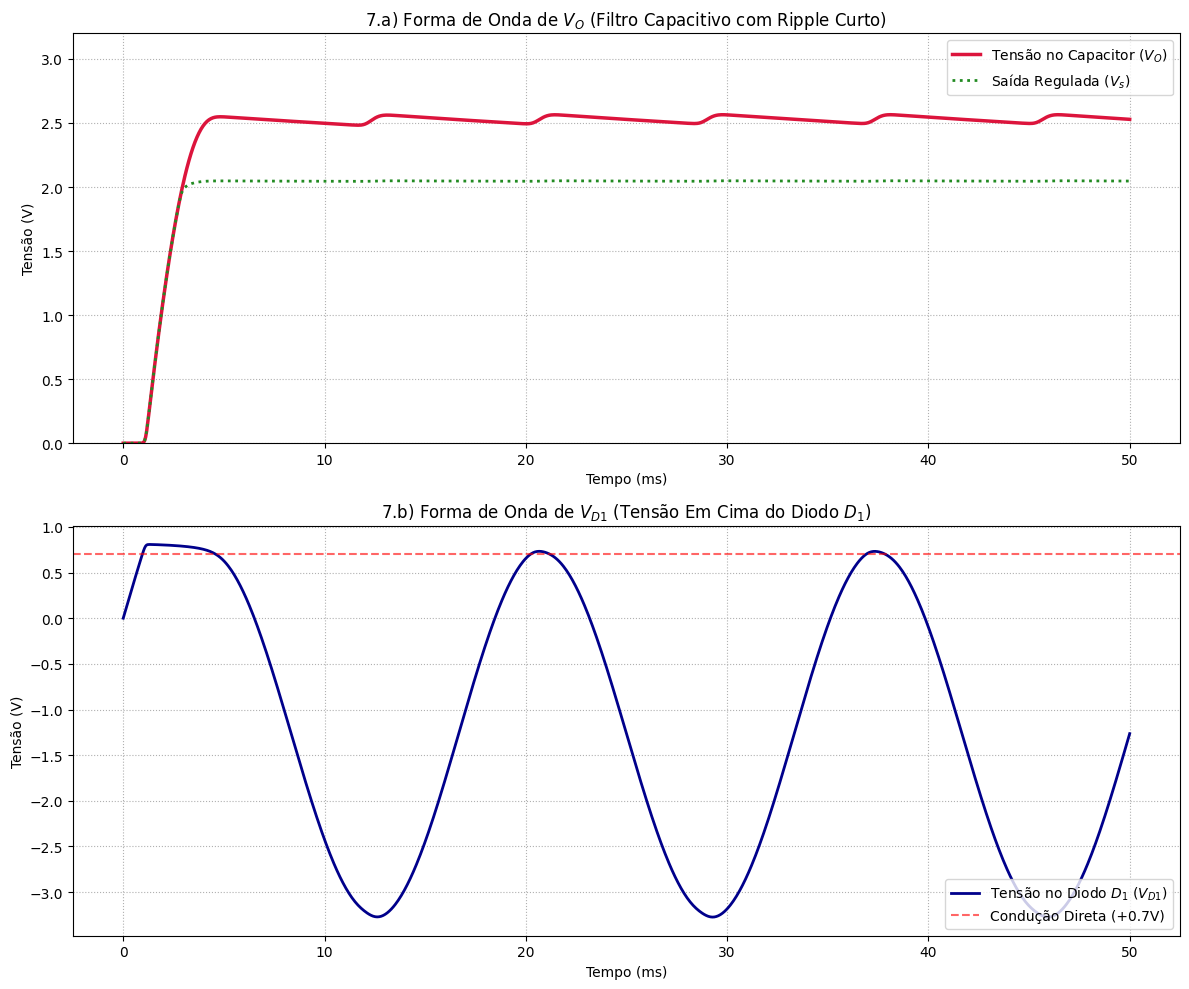

In [15]:
analysis = SpiceParser(path='netlists/q7/circuit.net').build_circuit().simulator().transient(step_time=50e-6, end_time=50e-3)


# Extração dos dados
t = analysis.time * 1000  # em ms
v_O = analysis['vo']      # Tensão no capacitor (7.a)
v_D1 = analysis['vi'] - analysis['vo']  # Tensão diferencial sobre D1 (7.b)
v_s = analysis['vs']      # Tensão regulada de saída

# --- PLOTAGEM DOS GRÁFICOS ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Gráfico 7.a: Forma de onda de Vo com ripple estável
ax1.plot(t, v_O, color='crimson', linewidth=2.5, label='Tensão no Capacitor ($V_O$)')
ax1.plot(t, v_s, color='forestgreen', linestyle=':', linewidth=2, label='Saída Regulada ($V_s$)')
ax1.set_title('7.a) Forma de Onda de $V_O$ (Filtro Capacitivo com Ripple Curto)')
ax1.set_xlabel('Tempo (ms)')
ax1.set_ylabel('Tensão (V)')
ax1.set_ylim(0, 3.2)
ax1.grid(True, linestyle=':')
ax1.legend(loc='upper right')

# Gráfico 7.b: Forma de onda de VD1
ax2.plot(t, v_D1, color='darkblue', linewidth=2, label='Tensão no Diodo $D_1$ ($V_{D1}$)')
ax2.axhline(0.7, color='red', linestyle='--', alpha=0.6, label='Condução Direta (+0.7V)')
ax2.set_title('7.b) Forma de Onda de $V_{D1}$ (Tensão Em Cima do Diodo $D_1$)')
ax2.set_xlabel('Tempo (ms)')
ax2.set_ylabel('Tensão (V)')
ax2.grid(True, linestyle=':')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

## 📝 Dicas de Verificação Analítica para os Alunos

Para confirmar se os resultados numéricos do simulador fazem sentido com suas contas teóricas, lembrem-se de validar os estados lógicos hipotéticos dos diodos:

1. **No Circuito A:** * O diodo da esquerda está diretamente polarizado pelo resistor conectado à fonte de $+10\text{ V}$. Ele conduz, fixando o nó central superior em $+0,6\text{ V}$.
   * O diodo da direita tem seu anodo nesse nó de $+0,6\text{ V}$ e também conduz devido ao caminho para a fonte de $-10\text{ V}$. Isso resulta na tensão final esperada de $V = 0\text{ V}$ ($0,6\text{ V} - V_D$).

2. **No Circuito B:**
   * Assuma inicialmente que o diodo está cortado (circuito aberto). O nó esquerdo ficaria em $5\text{ V}$ (divisor entre $10\text{ V}$ e GND) e o direito em $7,5\text{ V}$ (divisor entre $15\text{ V}$ e GND).
   * Como o potencial do anodo ($7,5\text{ V}$) é consideravelmente maior que o do catodo ($5\text{ V}$), a suposição de corte é falsa. O diodo conduz e fixa a diferença de potencial exatamente na tensão de condução ($V = 0,6\text{ V}$).